<div style="background:linear-gradient(135deg,#01172F 0%,#123B62 68%,#D9A441 140%);padding:30px;border-radius:18px;color:white;margin:8px 0 24px 0;box-shadow:0 8px 24px #01172F22">
  <div style="font-size:12px;letter-spacing:1.8px;font-weight:700;color:#E8C87E">LIA · ENTREGA 1.3 · 03 DE 03</div>
  <h1 style="margin:10px 0 8px 0;font-size:34px;line-height:1.16;color:white">RT-IoT2022: assinatura comportamental em redes IoT</h1>
  <p style="font-size:17px;line-height:1.55;margin:0 0 16px 0;color:#E8EEF5">Uma linha de base por dispositivo para reconhecer comportamento normal antes de procurar anomalias.</p>
  <span style="display:inline-block;background:#FFFFFF22;border:1px solid #FFFFFF55;padding:5px 10px;border-radius:999px;margin:3px 4px 0 0;font-size:12px">Pandas</span> <span style="display:inline-block;background:#FFFFFF22;border:1px solid #FFFFFF55;padding:5px 10px;border-radius:999px;margin:3px 4px 0 0;font-size:12px">Cybersecurity</span> <span style="display:inline-block;background:#FFFFFF22;border:1px solid #FFFFFF55;padding:5px 10px;border-radius:999px;margin:3px 4px 0 0;font-size:12px">IoT Analytics</span>
</div>

| 📦 Dataset | 📄 Arquivo | 📐 Dimensões | 🎯 Papel |
|---|---|---:|---|
| RT-IoT2022 (UCI #942) | `d3.csv` | **123.117 × 85** | Análise substantiva e síntese |

> **Saída deste notebook:** `resultados/entrega_1_3.json`

## ⚡ Em 30 segundos

- **37 de 80** variáveis separam os três dispositivos em operação normal.
- As variáveis temporais (`idle.*` e `*_iat.*`) concentram a assinatura comportamental.
- O limiar de anomalia deve ser calibrado **por dispositivo**, não globalmente.

## 🗺️ Roteiro do notebook

| | Etapa | O que acontece |
|---:|---|---|
| 🩺 | **Triar** | desbalanceamento, assinaturas definicionais e redundância |
| 📡 | **Perfilar** | comportamento normal por dispositivo |
| ⚖️ | **Comparar** | tráfego normal, ataques e proveniência |
| 🧩 | **Sintetizar** | consolidar as três entregas |

> ▶️ **Como usar:** execute as células de cima para baixo. A primeira célula monta o Drive, confere os arquivos e prepara o ambiente.

---

## 🎯 1. Escopo

### 1.1 Questão de pesquisa

> Os dispositivos IoT em operação normal possuem assinatura comportamental própria, suficiente para constituir linha de base de um detector de anomalia?

### 1.2 Papel na Entrega 1

Um detector de anomalia em rede operacional requer linha de base por dispositivo
antes de poder apontar desvio. Se os dispositivos normais não se distinguem entre si,
não há linha de base a construir e resta apenas detecção por assinatura.

A Seção 6 demonstra por que classificação multiclasse supervisionada é enquadramento
inadequado para este conjunto, e a Seção 8 responde à questão acima.

### 1.3 Pré-requisitos de execução

- Entregas 1.1 e 1.2 executadas — a síntese da Seção 12 lê os JSONs produzidos por elas
- Noções de tráfego de rede: fluxo, flags TCP, intervalo entre chegadas
- `nucleo.py`, `titanic.csv` e `d3.csv` no diretório apontado por `DADOS`


---

## 🧭 2. Matriz de rastreabilidade

Mapa rápido entre o desafio, a seção e a evidência gerada.

| Requisito | Seção | Evidência produzida |
|---|---|---|
| Limpeza dos dados | 5 e 7 | duplicatas, coluna constante, colunas derivadas |
| Análise exploratória | 5, 6, 8 e 9 | triagem, cruzamentos, agregações múltiplas |
| Visualizações informativas | 6, 8, 9 e 12 | distribuição, comparação, correlação, Pareto |
| Identificação de insights | 6, 8 e 12 | três achados metodológicos e um substantivo |
| Conclusões e recomendações | 13 | quatro recomendações operacionais |


---

## 📐 3. Convenções e premissas

### 3.1 Convenções estatísticas

Fixadas em `nucleo.CONVENCOES` e idênticas nas três entregas. A célula de
calibração da Seção 4 interrompe a execução se qualquer uma divergir.

| Convenção | Valor adotado | Alternativa comum | Efeito da troca |
|---|---|---|---|
| Quantil | interpolação linear (tipo 7 de Hyndman–Fan) | tipo 1 (sem interpolação) | altera contagem de outliers |
| Desvio padrão | `ddof=1` (amostral) | `ddof=0` (populacional, padrão do NumPy) | altera dispersão reportada |
| Outlier | regra de Tukey, `1,5 × IQR` | `3σ` | altera critério de exclusão |
| Correlação | Pearson | Spearman | altera sensibilidade a não-linearidade |

### 3.2 Premissas declaradas

**P1. Enquadramento** — perfilamento de linha de base, não classificação supervisionada. A justificativa quantitativa está na Seção 6.1.

**P2. Limitação do η²** — mede separação linear por média de grupo. Variável que separe por variância ou multimodalidade — plausível em tráfego de rede — pontua baixo e pode não ter sido detectada.

**P3. Ataques em bancada** — os ataques foram executados em laboratório, não capturados em produção. Generalização para rede operacional real não é reivindicada.

**P4. Ausência de balanceamento** — nenhuma reamostragem é aplicada. Reamostrar antes da análise exploratória descreveria a amostra sintética, não a rede — mesmo mecanismo do modo de falha I da Entrega 1.1. Balanceamento pertence ao estágio de modelagem, dentro do fold de treino.

**P5. Sem cruzamento entre conjuntos** — não há chave, entidade nem unidade de observação comum entre as três entregas. A unidade de uma linha é, respectivamente, um passageiro, um registro fabricado e um fluxo de rede. A comparação da Seção 11 é metodológica.



---

## ⚙️ 4. Preparação do ambiente

In [2]:
# @title ⚙️ Preparar ambiente e conferir arquivos
import importlib.util
import json
import math
import os
import subprocess
import sys
import urllib.request
from pathlib import Path

# Caminho principal no Google Drive. No Colab, você pode editar pelo formulário.
PASTA_PROJETO = "/content/drive/MyDrive/Entrega1"  # @param {"type":"string"}
try:
    EM_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    EM_COLAB = False

if EM_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    DADOS = Path(PASTA_PROJETO)
else:
    DADOS = Path.cwd()

if not DADOS.exists():
    raise FileNotFoundError(
        f"Pasta não encontrada: {DADOS}\n"
        "Crie MyDrive/Entrega1, envie o pacote e execute esta célula novamente."
    )

os.chdir(DADOS)
sys.path.insert(0, str(DADOS))
Path("resultados").mkdir(exist_ok=True)

# Arquivos didáticos pequenos: baixa somente se ainda não estiverem na pasta.
DOWNLOADS = {
    "titanic.csv": "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv",
    "iris.csv": "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv",
}
for nome, url in DOWNLOADS.items():
    if not Path(nome).exists():
        print(f"⬇️ Baixando {nome}...")
        urllib.request.urlretrieve(url, nome)

# Instala apenas o que estiver ausente no ambiente atual.
PACOTES = {
    "numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib",
    "seaborn": "seaborn", "scipy": "scipy", "pyarrow": "pyarrow",
}
faltam_pacotes = [pacote for modulo, pacote in PACOTES.items()
                   if importlib.util.find_spec(modulo) is None]
if faltam_pacotes:
    print("📦 Instalando:", ", ".join(faltam_pacotes))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *faltam_pacotes])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import stats

import nucleo as nu

nu.aplicar_estilo()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 30)

ITENS = {
    "nucleo.py": "módulo compartilhado",
    "titanic.csv": "calibração",
    "iris.csv": "teste de quantis e correlação",
    "d2.csv": "IoT Security & Energy",
    "d3.csv": "RT-IoT2022",
    "resultados/entrega_1_1.json": "resultado da etapa 1.1",
    "resultados/entrega_1_2.json": "resultado da etapa 1.2",
}
painel = pd.DataFrame([
    {"status": "✅ OK" if Path(arquivo).exists() else "⬜ pendente",
      "arquivo": arquivo, "papel": papel}
    for arquivo, papel in ITENS.items()
])
display(painel)

obrigatorios = ['nucleo.py', 'titanic.csv', 'd3.csv', 'resultados/entrega_1_1.json', 'resultados/entrega_1_2.json']
faltando = [arquivo for arquivo in obrigatorios if not Path(arquivo).exists()]
if faltando:
    raise FileNotFoundError(
        "Arquivos necessários para esta etapa:\n- " + "\n- ".join(faltando)
    )

print(f"✅ Ambiente pronto · {DADOS}")
print("📐 Convenções:", nu.CONVENCOES)

Mounted at /content/drive


,status,arquivo,papel
0,✅ OK,nucleo.py,módulo compartilhado
1,✅ OK,titanic.csv,calibração
2,✅ OK,iris.csv,teste de quantis e correlação
3,✅ OK,d2.csv,IoT Security & Energy
4,✅ OK,d3.csv,RT-IoT2022
5,✅ OK,resultados/entrega_1_1.json,resultado da etapa 1.1
6,✅ OK,resultados/entrega_1_2.json,resultado da etapa 1.2


✅ Ambiente pronto · /content/drive/MyDrive/Entrega1
📐 Convenções: {'quantil': 'linear', 'ddof': 1, 'outlier': '1.5*IQR', 'corr': 'pearson'}


In [3]:
# @title ▶️ ⚙️ 4. Preparação do ambiente
# Regressão de convenções. Verifica 6 grupos do Titanic contra valores
# conhecidos. Interrompe a execução se qualquer convenção tiver mudado.
assert nu.calibrar("titanic.csv"), "convenções divergiram — investigar antes de prosseguir"

calibracao: OK -- 6/6 grupos, age nulos=177 | convencoes={'quantil': 'linear', 'ddof': 1, 'outlier': '1.5*IQR', 'corr': 'pearson'}


---

## 🔍 5. Auditoria de entrada

### 5.1 Integridade, perfil e duplicatas

> 🎯 **Pergunta:** Caracterizar o arquivo e identificar colunas inutilizáveis.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Verificação de integridade, perfil por coluna e contagem de duplicatas. A expectativa inicial é de que varreduras repetidas produzam registros idênticos; a Seção verifica se isso ocorre.

</details>

In [4]:
# @title ▶️ 5.1 Integridade, perfil e duplicatas
df = nu.carregar("d3.csv", categoricas=("proto", "service", "Attack_type"))

integridade = nu.integridade("d3.csv", df)
print("Integridade:", integridade)
print(f"Dimensões: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

perfil = nu.perfil(df)
constantes = list(perfil[perfil.constante].coluna)
print(f"Colunas com ausências.: {(perfil.nulos > 0).sum()}")
print(f"Colunas constantes....: {constantes}")

dup = int(df.duplicated().sum())
print(f"Duplicatas de linha inteira: {dup:,} ({dup/len(df):.2%})")
if dup:
    print("Distribuição das duplicatas por classe:")
    print(df[df.duplicated(keep=False)]["Attack_type"].value_counts().head(6).to_string())

Integridade: {'md5': '87ec8763e33f', 'linhas_wc': 123117, 'linhas_parser': 123117, 'confere': True}
Dimensões: 123,117 linhas × 85 colunas
Colunas com ausências.: 0
Colunas constantes....: ['bwd_URG_flag_count']
Duplicatas de linha inteira: 0 (0.00%)


> ✅ **Leitura principal**
>
> **123.117 linhas**, coincidente com a contagem publicada na fonte
> primária, e a contagem bruta confere com o parser.

**Zero ausências em 85 colunas.** Diferentemente da Entrega 1.2, aqui isso é esperado:
as colunas são *derivadas* pelo Flowmeter a partir do fluxo completo, não campos
observados diretamente. Não existe a condição "campo não observado".

Esta é uma observação metodológica relevante: **o mesmo fato admite leituras opostas
conforme o processo gerador**. Na Entrega 1.2 a ausência de valores faltantes era
indício, porque o esquema declarava captura direta. Auditoria exige compreender a
origem, não apenas aplicar testes.

`bwd_URG_flag_count` é constante — dado morto. Deve ser excluída de qualquer matriz de
correlação, sob pena de produzir `NaN` e contaminar o resultado.

**Zero duplicatas de linha inteira** em 123.117 registros. Este resultado contraria a
expectativa inicial — varreduras repetidas produziriam fluxos aparentemente idênticos.

A explicação está na construção das variáveis: o Flowmeter deriva 85 métricas contínuas
por fluxo, incluindo durações e intervalos entre chegadas com resolução de microssegundo.
Dois fluxos podem ser semanticamente equivalentes e ainda assim divergir na sexta casa
decimal de qualquer uma das 85 colunas.

**A ausência de duplicatas aqui não significa ausência de repetição semântica.** Detectar
fluxos equivalentes exigiria comparação por subconjunto de colunas discretas
(`proto`, `service`, portas), não igualdade exata. O contraste com a Entrega 1.1 é
instrutivo: lá a baixa dimensionalidade efetiva do registro produziu 107 coincidências
legítimas; aqui a alta dimensionalidade contínua as torna praticamente impossíveis.

---

## 🩺 6. Triagem

In [5]:
# @title ▶️ 🩺 6. Triagem
triagem = nu.triagem(df, "Attack_type", top=18)

=== TRIAGEM: 123,117 linhas x 85 colunas | alvo='Attack_type' ===

[1] CLASSES (12) -- desbalanceamento 3381:1
    DOS_SYN_Hping                        94,659  76.89%
    Thing_Speak                           8,108   6.59%
    ARP_poisioning                        7,750   6.29%
    MQTT_Publish                          4,146   3.37%
    NMAP_UDP_SCAN                         2,590   2.10%
    NMAP_XMAS_TREE_SCAN                   2,010   1.63%
    NMAP_OS_DETECTION                     2,000   1.62%
    NMAP_TCP_scan                         1,002   0.81%
    DDOS_Slowloris                          534   0.43%
    Wipro_bulb                              253   0.21%
    Metasploit_Brute_Force_SSH               37   0.03%
    NMAP_FIN_SCAN                            28   0.02%
    acuracia da classe majoritaria sozinha: 76.89%

[2] COLUNAS CONSTANTES (inuteis): 1 -> bwd_URG_flag_count

[3] SUSPEITOS DE VAZAMENTO: nenhum

[4] PODER DE SEPARACAO (eta^2), top 18 de 81 numericas:
    fwd_URG_fl

### 6.1 Desbalanceamento e o limite da acurácia global

> 🎯 **Pergunta:** Quantificar o desbalanceamento e estabelecer o patamar de referência que qualquer classificador precisa superar.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Distribuição de frequência das classes, razão entre a maior e a menor, e acurácia do classificador constante. Complementa-se com a curva de Pareto acumulada.

**📐 Critério técnico**

Seja $p_{\max}$ a proporção da classe majoritária. O classificador que responde
sempre a classe majoritária atinge

$$\text{Acurácia}_{\text{trivial}} = p_{\max}$$

sem qualquer capacidade preditiva. Toda acurácia global reportada abaixo desse valor
indica desempenho inferior à regra constante.

</details>

In [6]:
# @title ▶️ 6.1 Desbalanceamento e o limite da acurácia global
vc = df["Attack_type"].value_counts()
razao = vc.max() / vc.min()
p_max = vc.max() / len(df)

print(f"Classes...........................: {len(vc)}")
print(f"Desbalanceamento (maior : menor)..: {razao:.0f} : 1")
print(f"Acurácia do classificador trivial.: {p_max:.2%}")
print()
tabela = pd.DataFrame({"n": vc, "proporção": (vc / len(df)).round(4)})
tabela["acumulado"] = tabela["proporção"].cumsum().round(4)
display(tabela)

Classes...........................: 12
Desbalanceamento (maior : menor)..: 3381 : 1
Acurácia do classificador trivial.: 76.89%



,n,proporção,acumulado
Attack_type,,,
DOS_SYN_Hping,94659,0.7689,0.7689
Thing_Speak,8108,0.0659,0.8348
ARP_poisioning,7750,0.0629,0.8977
MQTT_Publish,4146,0.0337,0.9314
NMAP_UDP_SCAN,2590,0.0210,0.9524
NMAP_XMAS_TREE_SCAN,2010,0.0163,0.9687
NMAP_OS_DETECTION,2000,0.0162,0.9849
NMAP_TCP_scan,1002,0.0081,0.9930
DDOS_Slowloris,534,0.0043,0.9973


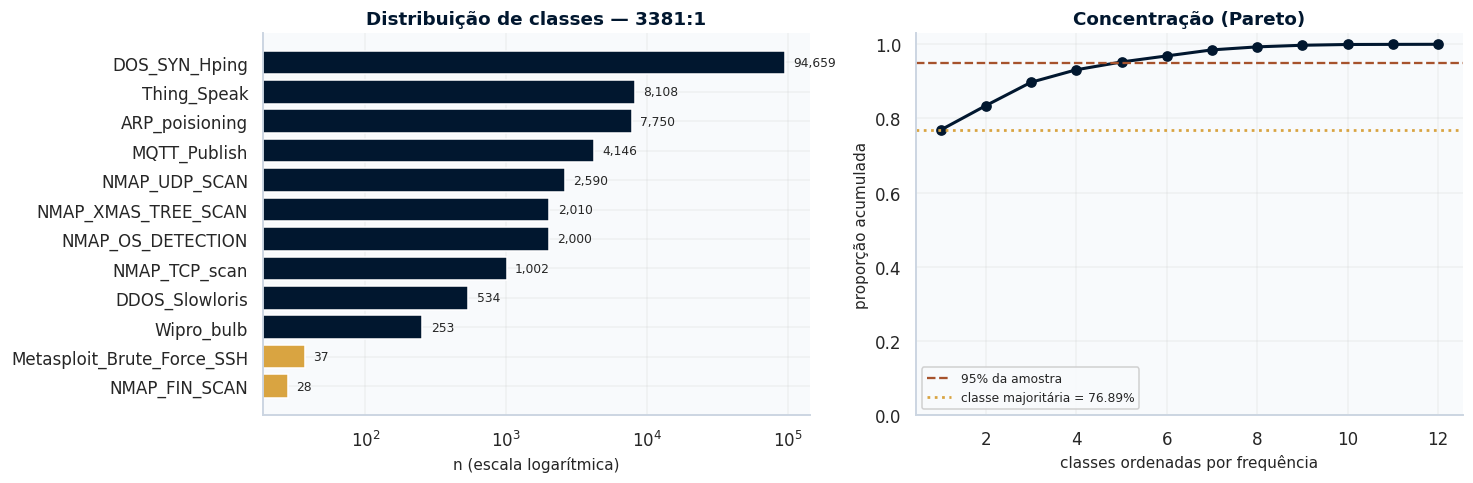

In [7]:
# @title ▶️ 6.1 Desbalanceamento e o limite da acurácia global
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.5))

cores = [nu.PALETA["gold"] if n < 100 else nu.PALETA["navy"] for n in vc.values[::-1]]
ax[0].barh(vc.index[::-1].astype(str), vc.values[::-1], color=cores)
ax[0].set_xscale("log"); ax[0].set_xlabel("n (escala logarítmica)")
ax[0].set_title(f"Distribuição de classes — {razao:.0f}:1")
for i, v in enumerate(vc.values[::-1]):
    ax[0].text(v * 1.15, i, f"{v:,}", va="center", fontsize=8)

acum = (vc / len(df)).cumsum().values
ax[1].plot(range(1, len(acum) + 1), acum, marker="o", color=nu.PALETA["navy"], lw=2)
ax[1].axhline(.95, color=nu.PALETA["rust"], ls="--", lw=1.5, label="95% da amostra")
ax[1].axhline(p_max, color=nu.PALETA["gold"], ls=":", lw=1.8,
              label=f"classe majoritária = {p_max:.2%}")
ax[1].set_xlabel("classes ordenadas por frequência")
ax[1].set_ylabel("proporção acumulada")
ax[1].set_title("Concentração (Pareto)"); ax[1].legend(fontsize=8)
ax[1].set_ylim(0, 1.03)

plt.tight_layout(); plt.show()

> ✅ **Leitura principal**
>
> **Desbalanceamento de 3.381 : 1.** A classe `DOS_SYN_Hping`
> concentra 76,89% da amostra; um classificador constante atinge essa acurácia sem
> detectar coisa alguma.

A curva de Pareto mostra que **quatro das doze classes cobrem mais de 95% da amostra**.
As duas menores possuem 37 e 28 registros: em partição estratificada 80/20 restam
aproximadamente sete e seis no conjunto de teste, e qualquer métrica calculada sobre
elas é ruído amostral.

**Consequência para o enquadramento.** Classificação multiclasse supervisionada
reportaria acurácia global próxima de $p_{\max}$ com métricas sem sentido nas classes
raras. Esta é a justificativa quantitativa para a escolha de perfilamento de linha de
base, declarada na premissa P1.

### 6.2 Separação quase perfeita: assinatura ou aprendizado?

> 🎯 **Pergunta:** Investigar a variável de maior η² antes de interpretá-la como sinal preditivo.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Tabulação cruzada entre a variável de maior separação e a classe alvo, seguida de verificação de coerência com a definição do ataque.

</details>

In [8]:
# @title ▶️ 6.2 Separação quase perfeita: assinatura ou aprendizado?
eta_xmas = nu._eta2(df, "fwd_URG_flag_count", "Attack_type")
print(f"η² de fwd_URG_flag_count sobre Attack_type: {eta_xmas:.4f}")
pd.crosstab(df["fwd_URG_flag_count"], df["Attack_type"]).T

η² de fwd_URG_flag_count sobre Attack_type: 0.9980


fwd_URG_flag_count,0,1
Attack_type,,
ARP_poisioning,7750,0
DDOS_Slowloris,534,0
DOS_SYN_Hping,94659,0
MQTT_Publish,4146,0
Metasploit_Brute_Force_SSH,37,0
NMAP_FIN_SCAN,28,0
NMAP_OS_DETECTION,2000,0
NMAP_TCP_scan,1002,0
NMAP_UDP_SCAN,2590,0


> ✅ **Leitura principal**
>
> **A separação não constitui vazamento — constitui definição.**

A flag URG está ativa em 2.006 dos 2.010 registros de `NMAP_XMAS_TREE_SCAN`, e em zero
das demais 121 mil linhas. Uma varredura *Xmas tree* é, por definição, um pacote com as
flags FIN, PSH e URG simultaneamente ativas. A variável é **causalmente posterior à
definição do ataque**.

Um modelo que aprende esta coluna não descobriu padrão: redescobriu a definição.

| | Detecção por assinatura | Detecção de anomalia |
|---|---|---|
| Mecanismo | regra determinística sobre campo conhecido | desvio de comportamento aprendido |
| Caso presente | `fwd_URG_flag_count == 1` → Xmas scan | alteração do perfil temporal do dispositivo |
| Requer aprendizado de máquina | não | sim |
| Detecta ataque desconhecido | não | possivelmente |
| Custo de manutenção | atualização da base de regras | recalibração da linha de base |

Reportar acurácia elevada em conjunto onde uma flag resolve uma classe inteira mede a
assinatura, não o modelo.

### 6.3 Redundância estrutural entre variáveis

> 🎯 **Pergunta:** Quantificar a colinearidade introduzida pela construção bidirecional das métricas de fluxo.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Matriz de correlação absoluta sobre as variáveis com variância, e contagem de pares acima de 0,95. A coluna constante é excluída previamente para não produzir `NaN`.

</details>

In [9]:
# @title ▶️ 6.3 Redundância estrutural entre variáveis
num_var = [c for c in df.select_dtypes(include=[np.number]).columns
           if df[c].nunique() > 1]
cc = df[num_var].corr().abs()

pares = [(a, b, cc.loc[a, b]) for i, a in enumerate(cc.columns)
         for b in cc.columns[i+1:] if cc.loc[a, b] > .95]

print(f"Variáveis numéricas com variância: {len(num_var)}")
print(f"Pares com |r| > 0,95............: {len(pares)}")
print(f"|r| máximo.....................: {max(p[2] for p in pares):.6f}")
display(pd.DataFrame(pares, columns=["variável A", "variável B", "|r|"])
        .sort_values("|r|", ascending=False).head(12).reset_index(drop=True))

Variáveis numéricas com variância: 81
Pares com |r| > 0,95............: 52
|r| máximo.....................: 1.000000


,variável A,variável B,|r|
0,flow_duration,flow_iat.tot,1.000000
1,bwd_pkts_per_sec,flow_pkts_per_sec,0.999997
2,fwd_pkts_per_sec,flow_pkts_per_sec,0.999997
3,fwd_pkts_per_sec,bwd_pkts_per_sec,0.999986
4,bwd_bulk_bytes,bwd_bulk_packets,0.999802
5,flow_iat.max,idle.max,0.999748
6,fwd_iat.tot,flow_iat.tot,0.999719
7,flow_duration,fwd_iat.tot,0.999719
8,fwd_iat.max,flow_iat.max,0.996647
9,fwd_iat.max,idle.max,0.996389


> ✅ **Leitura principal**
>
> **52 pares com |r| > 0,95**, alguns próximos de 1,000 — informação
> duplicada.

A origem é construtiva: para cada métrica `fwd_*` existe uma `bwd_*`, e as famílias
`idle.*` e `*_iat.*` medem o mesmo fenômeno temporal sob parametrizações distintas.

É o mesmo problema estrutural de `fare` e `class` na Entrega 1.1, em escala maior:
tratar variáveis colineares como evidências independentes contabiliza a mesma
informação múltiplas vezes. **Redução de dimensionalidade é pré-requisito, não
refinamento opcional.**

---

## 🧹 7. Limpeza e transformação

### 7.1 Descarte, padronização e derivação

> 🎯 **Pergunta:** Produzir o conjunto de trabalho com transformações rastreáveis.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Descarte da coluna constante; padronização do marcador de serviço não identificado; derivação de faixa de duração por `pd.cut` com bordas em escala logarítmica, adequada a variável com amplitude de várias ordens de grandeza; derivação de indicador binário por `np.where`.

</details>

In [10]:
# @title ▶️ 7.1 Descarte, padronização e derivação
trab = df.drop(columns=constantes).copy()

# "-" é o marcador do Zeek para serviço não identificado: torná-lo explícito
trab["service"] = (trab["service"].astype(str).str.strip()
                   .replace("-", "nao_identificado").astype("category"))

# flow_duration cobre várias ordens de grandeza: bordas em escala log
BORDAS = [-0.001, 0.1, 1, 10, 100, np.inf]
ROTULOS = ["<0,1s", "0,1–1s", "1–10s", "10–100s", ">100s"]
trab["faixa_duracao"] = pd.cut(trab["flow_duration"], bins=BORDAS, labels=ROTULOS)

trab["e_ataque"] = np.where(
    trab["Attack_type"].isin(["Thing_Speak", "MQTT_Publish", "Wipro_bulb"]), "Normal", "Ataque")

print(f"Colunas: {df.shape[1]} → {trab.shape[1]}")
print(f"Fluxos fora das bordas de faixa_duracao: "
      f"{int(trab['flow_duration'].notna().sum() - trab['faixa_duracao'].notna().sum())}")
print()
print("Distribuição de service após padronização:")
print(trab["service"].value_counts().to_string())
print()
print("Distribuição normal × ataque:")
print(trab["e_ataque"].value_counts().to_string())

Colunas: 85 → 86
Fluxos fora das bordas de faixa_duracao: 0

Distribuição de service após padronização:
service
nao_identificado    102861
dns                   9753
mqtt                  4132
http                  3464
ssl                   2663
ntp                    121
dhcp                    50
irc                     43
ssh                     28
radius                   2

Distribuição normal × ataque:
e_ataque
Ataque    110610
Normal     12507


> ✅ **Leitura principal**
>
> O marcador `-` do Zeek significa serviço não identificado pelo
> analisador de protocolo, e representa a maioria dos fluxos. Mantê-lo como `-` faria com
> que aparecesse em gráficos como categoria sem significado aparente; renomeá-lo torna a
> condição explícita na leitura.

As bordas de `faixa_duracao` são declaradas em escala logarítmica porque
`flow_duration` cobre várias ordens de grandeza. Bordas equiespaçadas concentrariam
quase todos os fluxos em um único intervalo. A borda inferior `-0.001` inclui os fluxos
de duração exatamente zero, que existem neste conjunto.

---

## 📡 8. Assinatura comportamental dos dispositivos

Seção central da entrega. Responde à questão de pesquisa declarada na Seção 1.1.

### 8.1 Separação entre dispositivos em operação normal

> 🎯 **Pergunta:** Determinar se os três dispositivos, restritos ao tráfego sem ataque, se distinguem entre si.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Restrição do conjunto às três classes de tráfego normal e cálculo do η² de cada variável sobre a identidade do dispositivo. A restrição é necessária: incluir ataques mediria separação entre ataque e normal, não entre dispositivos.

</details>

In [11]:
# @title ▶️ 8.1 Separação entre dispositivos em operação normal
NORMAIS = ["Thing_Speak", "MQTT_Publish", "Wipro_bulb"]
sub = trab[trab["Attack_type"].isin(NORMAIS)].copy()
sub["dispositivo"] = sub["Attack_type"].astype(str)

print(f"Fluxos normais: {len(sub):,}")
print(sub["dispositivo"].value_counts().to_string())

eta = pd.Series({c: nu._eta2(sub, c, "dispositivo")
                 for c in num_var if sub[c].nunique() > 1}).dropna().sort_values(ascending=False)

n_sep = int((eta > .1).sum())
print(f"\nVariáveis com η² > 0,1: {n_sep} de {len(eta)}")
display(eta.head(10).round(3).to_frame("η²"))

Fluxos normais: 12,507
dispositivo
Thing_Speak     8108
MQTT_Publish    4146
Wipro_bulb       253

Variáveis com η² > 0,1: 37 de 80


,η²
idle.min,0.716
idle.avg,0.702
fwd_iat.max,0.685
fwd_iat.std,0.681
flow_iat.max,0.680
idle.max,0.675
flow_iat.std,0.672
fwd_iat.avg,0.569
active.min,0.565
active.avg,0.527


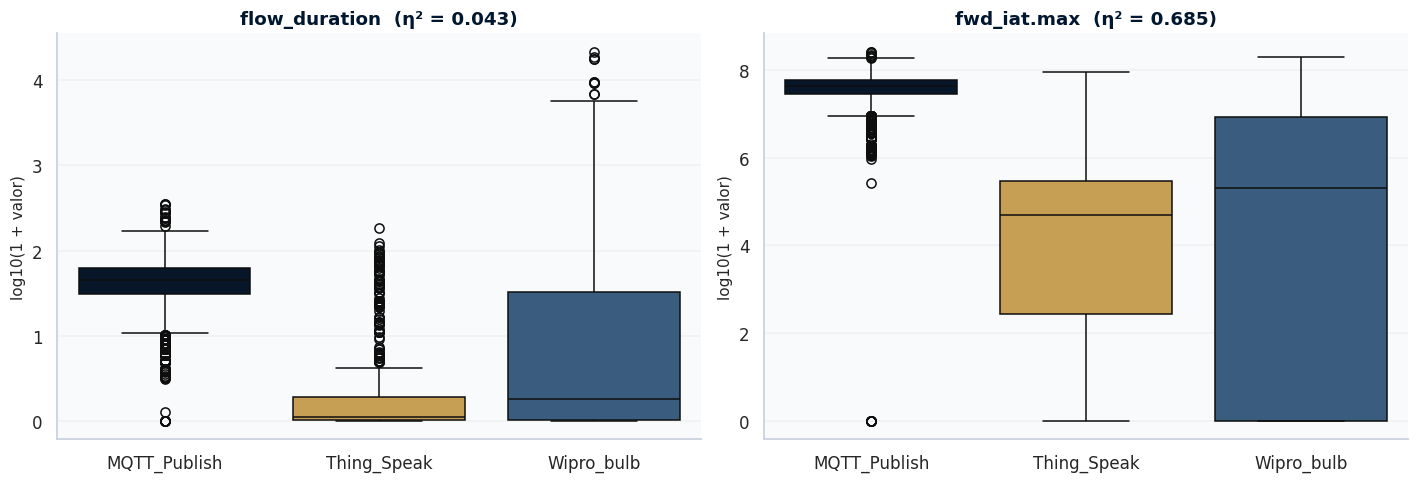

In [12]:
# @title ▶️ 8.1 Separação entre dispositivos em operação normal
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# log10(1 + x) preserva os zeros e evita eixos negativos artificiais.
sub_plot = sub.assign(
    flow_duration_log10=np.log10(1 + sub["flow_duration"].clip(lower=0)),
    fwd_iat_max_log10=np.log10(1 + sub["fwd_iat.max"].clip(lower=0)),
)
graficos = [
    ("flow_duration_log10", "flow_duration"),
    ("fwd_iat_max_log10", "fwd_iat.max"),
]
for i, (coluna_plot, feat) in enumerate(graficos):
    sns.boxplot(data=sub_plot, x="dispositivo", y=coluna_plot, ax=ax[i],
                hue="dispositivo", legend=False,
                palette=[nu.PALETA["navy"], nu.PALETA["gold"], nu.PALETA["steel"]])
    ax[i].set_title(f"{feat}  (η² = {eta[feat]:.3f})")
    ax[i].set_xlabel("")
    ax[i].set_ylabel("log10(1 + valor)")

plt.tight_layout(); plt.show()

> ✅ **Leitura principal**
>
> **Resposta afirmativa: 37 das 80 variáveis separam os três
> dispositivos entre si.**

A composição do topo da lista é coerente com o domínio: `idle.*` e `*_iat.*` são
variáveis **temporais**. Cada dispositivo apresenta ritmo próprio — o sensor de
temperatura MQTT publica em intervalo regular, a lâmpada transmite apenas quando
acionada, e o cliente ThingSpeak realiza requisições periódicas de telemetria.

**A assinatura reside no comportamento temporal, não no conteúdo do pacote.** A
implicação prática é relevante: conteúdo cifrado não impede o perfilamento.

A escala **symlog** é necessária, não estética. As distribuições cobrem várias ordens de
grandeza; em escala linear as três caixas ficariam comprimidas contra o eixo e a
separação seria invisível.

### 8.2 Perfil de serviço por dispositivo

> 🎯 **Pergunta:** Confirmar a separação pelo lado categórico das variáveis.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Tabulação cruzada entre dispositivo e serviço, normalizada por linha. A normalização é necessária porque os grupos têm tamanhos muito distintos — 8.108 contra 253 — e a contagem bruta indicaria apenas qual dispositivo é mais frequente.

</details>

Contagem bruta:


service,dhcp,dns,http,irc,mqtt,nao_identificado,ntp,ssl
dispositivo,,,,,,,,
MQTT_Publish,0,0,3,0,4132,11,0,0
Thing_Speak,14,4069,2667,0,0,151,110,1097
Wipro_bulb,5,53,0,43,0,45,0,107


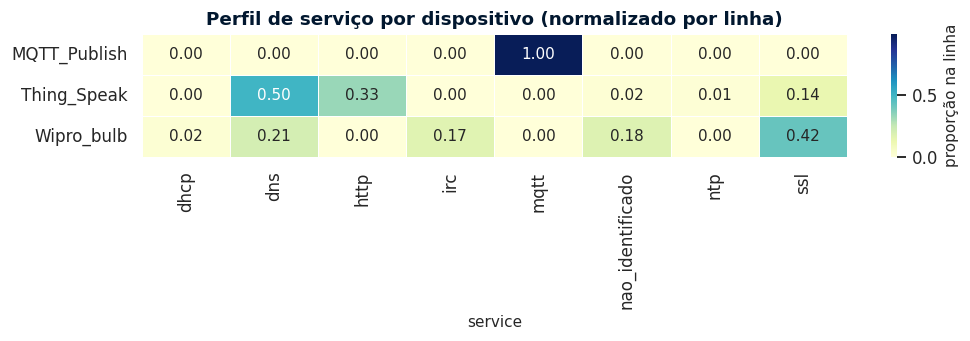

In [13]:
# @title ▶️ 8.2 Perfil de serviço por dispositivo
tab = pd.crosstab(sub["dispositivo"], sub["service"].astype(str))
tab = tab.loc[:, tab.sum() > 0]
print("Contagem bruta:"); display(tab)

norm = tab.div(tab.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(9.5, 3.2))
sns.heatmap(norm, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax,
            cbar_kws={"label": "proporção na linha"}, linewidths=.5, linecolor="white")
ax.set_title("Perfil de serviço por dispositivo (normalizado por linha)")
ax.set_ylabel("")
plt.tight_layout(); plt.show()

> ✅ **Leitura principal**
>
> | Dispositivo | Perfil de serviço |
> |---|---|
> | `MQTT_Publish` | quase exclusivamente `mqtt` |
> | `Thing_Speak` | combinação de `dns`, `http`, `ssl`, `ntp` |
> | `Wipro_bulb` | `ssl`, `dns`, `irc` |

O perfil categórico corrobora a separação temporal da Seção 8.1 por via independente.

### 8.3 Estabilidade da linha de base

> 🎯 **Pergunta:** Determinar se cada dispositivo é internamente consistente o suficiente para que um desvio seja detectável.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Cálculo do coeficiente quartílico de dispersão sobre `flow_duration`, e da proporção de zeros em `idle.min`. Separar grupos é condição necessária mas não suficiente: a linha de base exige consistência **dentro** do grupo.

**📐 Critério técnico**

$$\text{QCD} = \frac{Q_3 - Q_1}{Q_3 + Q_1} \in [0,1]$$

Adimensional e robusto a outliers. Valor próximo de 0 indica comportamento regular;
próximo de 1, errático.

A razão $IQR/\text{mediana}$ seria a escolha intuitiva, mas é **indefinida quando a
mediana é zero** — condição frequente em métricas de rede com inflação de zeros. O QCD
falha apenas se $Q_1 = Q_3 = 0$.

</details>

In [14]:
# @title ▶️ 8.3 Estabilidade da linha de base
FEAT = "flow_duration"
est = sub.groupby("dispositivo", observed=True)[FEAT].agg(
    n="size", mediana="median",
    q1=lambda s: s.quantile(.25, interpolation=nu.CONVENCOES["quantil"]),
    q3=lambda s: s.quantile(.75, interpolation=nu.CONVENCOES["quantil"]))
est["IQR"] = est["q3"] - est["q1"]
est["QCD"] = ((est["q3"] - est["q1"]) / (est["q3"] + est["q1"])).round(3)
display(est.round(4))

infl = sub.groupby("dispositivo", observed=True)[["idle.min", FEAT]].apply(
    lambda g: (g == 0).mean()).round(3)
print("Proporção de zeros:"); print(infl.to_string())

,n,mediana,q1,q3,IQR,QCD
dispositivo,,,,,,
MQTT_Publish,4146,44.0676,30.0230,61.9730,31.9500,0.347
Thing_Speak,8108,0.1148,0.0299,0.8782,0.8482,0.934
Wipro_bulb,253,0.8033,0.0277,31.2854,31.2577,0.998


Proporção de zeros:
              idle.min  flow_duration
dispositivo                          
MQTT_Publish     0.050          0.002
Thing_Speak      0.989          0.022
Wipro_bulb       0.684          0.036


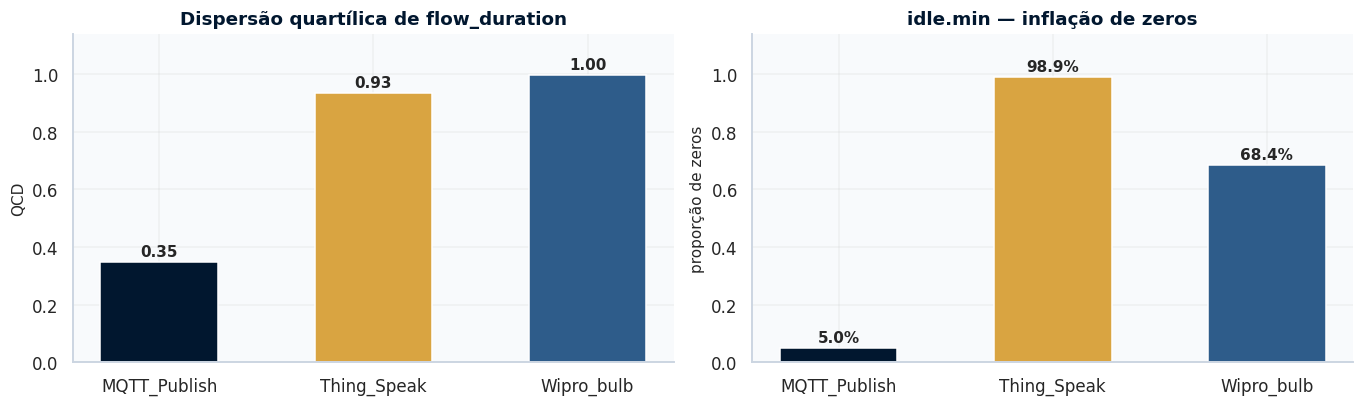

In [15]:
# @title ▶️ 8.3 Estabilidade da linha de base
fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
cores = [nu.PALETA["navy"], nu.PALETA["gold"], nu.PALETA["steel"]]

ax[0].bar(est.index, est["QCD"], color=cores, width=.55)
ax[0].set_ylabel("QCD"); ax[0].set_ylim(0, 1.14)
ax[0].set_title(f"Dispersão quartílica de {FEAT}")
for i, v in enumerate(est["QCD"]):
    ax[0].text(i, v + .02, f"{v:.2f}", ha="center", fontweight="bold")

ax[1].bar(infl.index, infl["idle.min"], color=cores, width=.55)
ax[1].set_ylabel("proporção de zeros"); ax[1].set_ylim(0, 1.14)
ax[1].set_title("idle.min — inflação de zeros")
for i, v in enumerate(infl["idle.min"]):
    ax[1].text(i, v + .02, f"{v:.1%}", ha="center", fontweight="bold")

plt.tight_layout(); plt.show()

> ✅ **Leitura principal**
>
> | Dispositivo | QCD | Zeros em `idle.min` | Caracterização |
> |---|---|---|---|
> | `MQTT_Publish` | **0,347** | 5,0% | regular — publicação periódica |
> | `Thing_Speak` | **0,934** | 98,9% | errático |
> | `Wipro_bulb` | **0,998** | 68,4% | altamente errático — acionamento humano |

**A inflação de zeros constitui, ela própria, dimensão de assinatura.** Um sensor
periódico apresenta tempo ocioso mensurável entre publicações; um cliente HTTP de
telemetria, não. A diferença entre 5,0% e 98,9% é discriminante por si só.

**Implicação operacional.** Um limiar de anomalia calibrado no comportamento do MQTT
(QCD 0,35) e aplicado ao `Wipro_bulb` (QCD 1,00) produziria alarme praticamente
contínuo. **O limiar precisa ser calibrado por dispositivo.**

---

## 📊 9. Cruzamentos e agregações

Aplicação das técnicas de agregação sobre o conjunto completo, incluindo ataques.

### 9.1 Protocolo por classe de ataque

> 🎯 **Pergunta:** Verificar se o protocolo de transporte discrimina as classes.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Tabela dinâmica de contagem por classe e protocolo, com a duração mediana de fluxo como segunda métrica. Duas agregações sobre o mesmo cruzamento.

</details>

In [16]:
# @title ▶️ 9.1 Protocolo por classe de ataque
pv_n = trab.pivot_table(values="flow_duration", index="Attack_type", columns="proto",
                        aggfunc="count", fill_value=0, observed=True)
pv_med = trab.pivot_table(values="flow_duration", index="Attack_type", columns="proto",
                          aggfunc="median", observed=True)

print("Contagem de fluxos:"); display(pv_n)
print("Duração mediana do fluxo (s):"); display(pv_med.round(4))

print("Cobertura de protocolo por classe (proporção na linha):")
display((pv_n.div(pv_n.sum(axis=1), axis=0)).round(3))

Contagem de fluxos:


proto,icmp,tcp,udp
Attack_type,,,
ARP_poisioning,8,1927,5815
DDOS_Slowloris,0,529,5
DOS_SYN_Hping,0,94659,0
MQTT_Publish,0,4146,0
Metasploit_Brute_Force_SSH,0,29,8
NMAP_FIN_SCAN,0,25,3
NMAP_OS_DETECTION,0,2000,0
NMAP_TCP_scan,0,1002,0
NMAP_UDP_SCAN,2,142,2446


Duração mediana do fluxo (s):


proto,icmp,tcp,udp
Attack_type,,,
ARP_poisioning,0.0000,10.2515,0.0002
DDOS_Slowloris,NaN,21.1665,0.0000
DOS_SYN_Hping,NaN,0.0000,NaN
MQTT_Publish,NaN,44.0676,NaN
Metasploit_Brute_Force_SSH,NaN,2.0662,0.0209
NMAP_FIN_SCAN,NaN,0.0000,0.0413
NMAP_OS_DETECTION,NaN,0.0000,NaN
NMAP_TCP_scan,NaN,0.0000,NaN
NMAP_UDP_SCAN,894.5356,0.0005,0.0000


Cobertura de protocolo por classe (proporção na linha):


proto,icmp,tcp,udp
Attack_type,,,
ARP_poisioning,0.001,0.249,0.750
DDOS_Slowloris,0.000,0.991,0.009
DOS_SYN_Hping,0.000,1.000,0.000
MQTT_Publish,0.000,1.000,0.000
Metasploit_Brute_Force_SSH,0.000,0.784,0.216
NMAP_FIN_SCAN,0.000,0.893,0.107
NMAP_OS_DETECTION,0.000,1.000,0.000
NMAP_TCP_scan,0.000,1.000,0.000
NMAP_UDP_SCAN,0.001,0.055,0.944


> ✅ **Leitura principal**
>
> O protocolo isola parcialmente as classes: as varreduras Nmap
> concentram-se em `tcp`, o tráfego MQTT também, e `icmp` aparece em subconjunto restrito.
> Nenhuma classe é resolvida apenas pelo protocolo — a informação é parcial.

`fill_value=0` foi aplicado à contagem, e **não** à mediana. A distinção é deliberada:
zero fluxos é informação legítima; duração mediana zero em célula vazia seria valor
fabricado indistinguível de duração real nula. Na Entrega 1.1 o mesmo cuidado foi
tomado com os `NaN` de faixa etária.

### 9.2 Duração de fluxo por natureza do tráfego

> 🎯 **Pergunta:** Comparar a distribuição de duração entre tráfego normal e de ataque.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Tabulação cruzada entre a faixa de duração derivada na Seção 7.1 e o indicador binário normal/ataque, com agregações múltiplas por classe.

</details>

In [17]:
# @title ▶️ 9.2 Duração de fluxo por natureza do tráfego
cruz = pd.crosstab(trab["faixa_duracao"], trab["e_ataque"], normalize="columns").round(4)
print("Distribuição de faixa de duração (proporção na coluna):"); display(cruz)

resumo = trab.groupby("e_ataque", observed=True)["flow_duration"].agg(
    n="size", mediana="median", q1=lambda s: s.quantile(.25),
    q3=lambda s: s.quantile(.75), desvio=nu.desvio)
display(resumo.round(4))

print("Descritivas por classe (5 maiores):")
display(trab[trab["Attack_type"].isin(vc.head(5).index)]
        .groupby("Attack_type", observed=True)["flow_duration"].describe().round(4))

Distribuição de faixa de duração (proporção na coluna):


e_ataque,Ataque,Normal
faixa_duracao,,
"<0,1s",0.9727,0.3279
"0,1–1s",0.0094,0.2347
1–10s,0.0050,0.1159
10–100s,0.0088,0.3175
>100s,0.0041,0.0040


,n,mediana,q1,q3,desvio
e_ataque,,,,,
Ataque,110610,0.0000,0.0000,0.0000,29.2218
Normal,12507,0.8794,0.0439,31.9051,397.7975


Descritivas por classe (5 maiores):


,count,mean,std,min,25%,50%,75%,max
Attack_type,,,,,,,,
ARP_poisioning,7750.0,15.8935,108.2611,0.0,0.0000,0.0006,0.3075,5341.3923
DOS_SYN_Hping,94659.0,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000
MQTT_Publish,4146.0,43.3970,24.3416,0.0,30.0230,44.0676,61.9730,353.1124
NMAP_UDP_SCAN,2590.0,0.7378,24.9098,0.0,0.0000,0.0000,0.0000,905.9642
Thing_Speak,8108.0,0.9345,5.2516,0.0,0.0299,0.1148,0.8782,184.4141


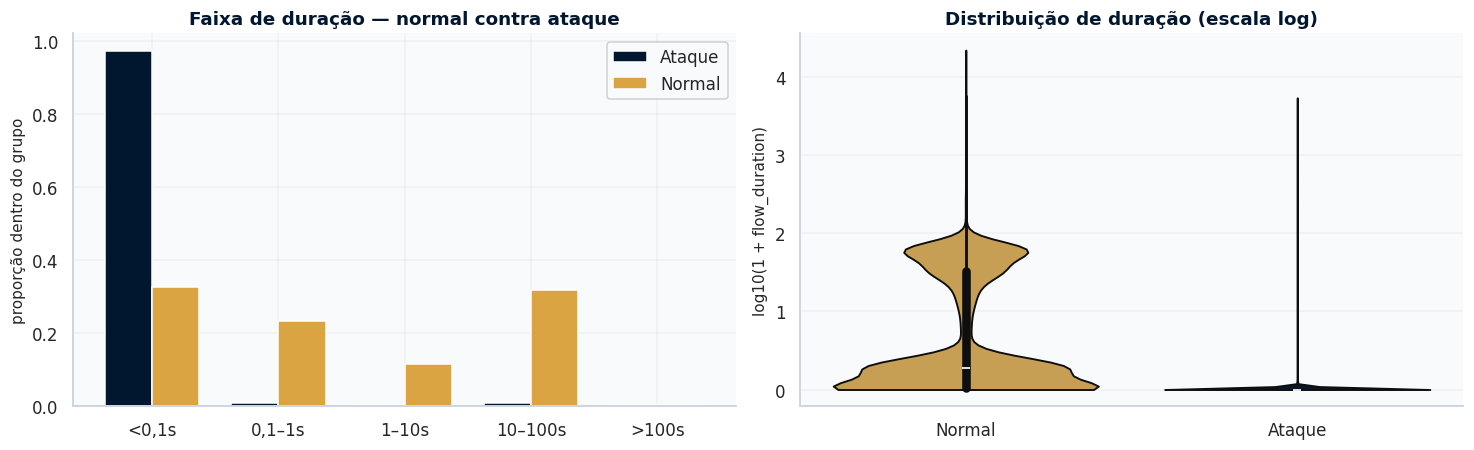

In [18]:
# @title ▶️ 9.2 Duração de fluxo por natureza do tráfego
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.2))

cruz.plot(kind="bar", ax=ax[0], color=[nu.PALETA["navy"], nu.PALETA["gold"]],
          edgecolor="white", width=.75)
ax[0].set_title("Faixa de duração — normal contra ataque")
ax[0].set_ylabel("proporção dentro do grupo"); ax[0].set_xlabel("")
ax[0].tick_params(axis="x", rotation=0); ax[0].legend(title="")

duracao_plot = trab.assign(
    flow_duration_log10=np.log10(1 + trab["flow_duration"].clip(lower=0))
)
sns.violinplot(data=duracao_plot, x="e_ataque", y="flow_duration_log10",
               ax=ax[1], hue="e_ataque", legend=False,
               palette=[nu.PALETA["gold"], nu.PALETA["navy"]], cut=0)
ax[1].set_title("Distribuição de duração (escala log)")
ax[1].set_xlabel(""); ax[1].set_ylabel("log10(1 + flow_duration)")

plt.tight_layout(); plt.show()

> ✅ **Leitura principal**
>
> O tráfego de ataque concentra-se em fluxos muito curtos, coerente
> com varreduras e inundação SYN, que não completam sessão. O tráfego normal distribui-se
> por faixas mais longas.

A separação existe mas **não é limpa**: ambos os grupos ocupam todas as faixas. Duração
isolada não constitui detector — é uma dimensão entre as 37 identificadas na Seção 8.1.

`cut=0` no diagrama de violino impede que a estimativa de densidade extrapole além do
suporte e sugira duração negativa, pelo mesmo motivo aplicado à idade na Entrega 1.1.

---

## 🧬 10. Controle negativo de proveniência

Aplicação do procedimento da Entrega 1.2 a este conjunto. Se ele classificasse também este como sintético, o veredito daquela entrega não seria auditável.

In [19]:
# @title ▶️ 🧬 10. Controle negativo de proveniência
veredito = nu.detectar_sintetico(df, "Attack_type")
for k, v in veredito.items():
    print(f"   {k:<30} {v}")

   uniformes                      (0, 82)
   sem_outliers                   (7, 82)
   corr_max_entre_features        0.9999999788564732
   eta2_max                       0.9979769884219944
   features_informativas          66
   sinais_de_sintetico            0
   veredito                       real ou inconclusivo


> ✅ **Leitura principal**
>
> **Zero sinais de sintético.** Nenhuma coluna compatível com
> uniforme, 66 variáveis informativas, |r| máximo próximo de 1,000 entre grandezas
> relacionadas.

Contraste com a Entrega 1.2 — 15 de 20 uniformes, uma variável informativa, |r| máximo
de 0,046. **Os dois vereditos decorrem do mesmo código e das mesmas convenções**, e a
Seção 8.2 daquela entrega verificou que a divergência não é artefato de tamanho
amostral.

---

## 💾 11. Registro dos achados

In [20]:
# @title ▶️ 💾 11. Registro dos achados
achados = {
    "entrega": "1.3",
    "dataset": "RT-IoT2022 (UCI ML Repository #942)",
    "md5": integridade["md5"],
    "linhas": int(len(df)), "colunas": int(df.shape[1]),
    "veredito_proveniencia": veredito["veredito"],
    "sinais_de_sintetico": veredito["sinais_de_sintetico"],
    "features_informativas": veredito["features_informativas"],
    "duplicatas": dup,
    "classes": int(df["Attack_type"].nunique()),
    "desbalanceamento": round(float(razao), 1),
    "acuracia_trivial_pct": round(100 * float(p_max), 2),
    "classes_criticas": {k: int(v) for k, v in vc.tail(3).items()},
    "colunas_constantes": constantes,
    "pares_colineares_r95": len(pares),
    "assinatura_definicional": {"feature": "fwd_URG_flag_count",
                                "classe": "NMAP_XMAS_TREE_SCAN",
                                "eta2": round(float(eta_xmas), 3)},
    "features_que_separam_dispositivos": n_sep,
    "total_features_avaliadas": int(len(eta)),
    "metrica_dispersao": "QCD = (Q3-Q1)/(Q3+Q1) sobre flow_duration",
    "qcd_por_dispositivo": {k: float(v) for k, v in est["QCD"].items()},
    "inflacao_zeros_idle_min": {k: round(float(v), 3) for k, v in infl["idle.min"].items()},
    "convencoes": nu.CONVENCOES,
}
json.dump(achados, open("resultados/entrega_1_3.json", "w"), indent=2, ensure_ascii=False)
print(json.dumps(achados, indent=2, ensure_ascii=False))

{
  "entrega": "1.3",
  "dataset": "RT-IoT2022 (UCI ML Repository #942)",
  "md5": "87ec8763e33f",
  "linhas": 123117,
  "colunas": 85,
  "veredito_proveniencia": "real ou inconclusivo",
  "sinais_de_sintetico": 0,
  "features_informativas": 66,
  "duplicatas": 0,
  "classes": 12,
  "desbalanceamento": 3380.7,
  "acuracia_trivial_pct": 76.89,
  "classes_criticas": {
    "Wipro_bulb": 253,
    "Metasploit_Brute_Force_SSH": 37,
    "NMAP_FIN_SCAN": 28
  },
  "colunas_constantes": [
    "bwd_URG_flag_count"
  ],
  "pares_colineares_r95": 52,
  "assinatura_definicional": {
    "feature": "fwd_URG_flag_count",
    "classe": "NMAP_XMAS_TREE_SCAN",
    "eta2": 0.998
  },
  "features_que_separam_dispositivos": 37,
  "total_features_avaliadas": 80,
  "metrica_dispersao": "QCD = (Q3-Q1)/(Q3+Q1) sobre flow_duration",
  "qcd_por_dispositivo": {
    "MQTT_Publish": 0.347,
    "Thing_Speak": 0.934,
    "Wipro_bulb": 0.998
  },
  "inflacao_zeros_idle_min": {
    "MQTT_Publish": 0.05,
    "Thing_Speak

---

## 🧩 12. Síntese das três entregas

A síntese lê os três JSONs já validados; nenhum resultado é recalculado.

In [21]:
# @title ▶️ 🧩 12. Síntese das três entregas
arquivos = {"1.1": "resultados/entrega_1_1.json",
            "1.2": "resultados/entrega_1_2.json",
            "1.3": "resultados/entrega_1_3.json"}

### 12.1 Verificação de compatibilidade

> 🎯 **Pergunta:** Confirmar que as três entregas empregaram convenções idênticas.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Comparação literal dos dicionários de convenções gravados em cada JSON. Divergência interrompe a execução: a comparação entre entregas com convenções distintas não teria base.

</details>

In [22]:
# @title ▶️ 12.1 Verificação de compatibilidade
faltando = [k for k, f in arquivos.items() if not os.path.exists(f)]
assert not faltando, f"execute primeiro as entregas: {faltando}"

R = {k: json.load(open(f)) for k, f in arquivos.items()}
conv = {json.dumps(v["convencoes"], sort_keys=True) for v in R.values()}
assert len(conv) == 1, "CONVENÇÕES DIVERGENTES entre as entregas — comparação inválida"

print("Convenções idênticas nas três entregas:")
for k, v in R["1.1"]["convencoes"].items():
    print(f"   {k:<10} {v}")

Convenções idênticas nas três entregas:
   quantil    linear
   ddof       1
   outlier    1.5*IQR
   corr       pearson


> ✅ **Leitura principal**
>
> Esta verificação é a justificativa técnica para a existência de um
> módulo compartilhado. Fossem as três entregas notebooks independentes, cada uma
> redefiniria `ddof` e o método de quantil, e a comparação da Seção 12.2 careceria de
> base. A divergência aqui **interrompe a execução** em vez de emitir aviso.

### 12.2 Quadro comparativo

> 🎯 **Pergunta:** Consolidar as três entregas em uma tabela única.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Leitura dos JSONs e composição da tabela. Nenhum valor é recalculado.

</details>

In [23]:
# @title ▶️ 12.2 Quadro comparativo
quadro = pd.DataFrame([
    {"entrega": "1.1 Titanic", "papel": "calibração",
     "linhas": R["1.1"]["linhas"], "colunas": R["1.1"]["colunas"],
     "proveniência": "canônica", "veredito": "real",
     "vars. informativas": "—", "vazamento": ", ".join(R["1.1"]["vazamento"])},
    {"entrega": "1.2 IoT/Energia", "papel": "controle",
     "linhas": R["1.2"]["linhas"], "colunas": R["1.2"]["colunas"],
     "proveniência": "declarada, sem lastro", "veredito": R["1.2"]["veredito"],
     "vars. informativas": R["1.2"]["features_informativas"],
     "vazamento": ", ".join(R["1.2"]["vazamento"])},
    {"entrega": "1.3 RT-IoT2022", "papel": "objeto de estudo",
     "linhas": R["1.3"]["linhas"], "colunas": R["1.3"]["colunas"],
     "proveniência": "documentada (UCI #942)",
     "veredito": R["1.3"]["veredito_proveniencia"],
     "vars. informativas": R["1.3"]["features_informativas"], "vazamento": "nenhum"},
]).set_index("entrega")
quadro

,papel,linhas,colunas,proveniência,veredito,vars. informativas,vazamento
entrega,,,,,,,
1.1 Titanic,calibração,891,15,canônica,real,—,alive
1.2 IoT/Energia,controle,4000,24,"declarada, sem lastro",sintetico,1,LABEL
1.3 RT-IoT2022,objeto de estudo,123117,85,documentada (UCI #942),real ou inconclusivo,66,nenhum


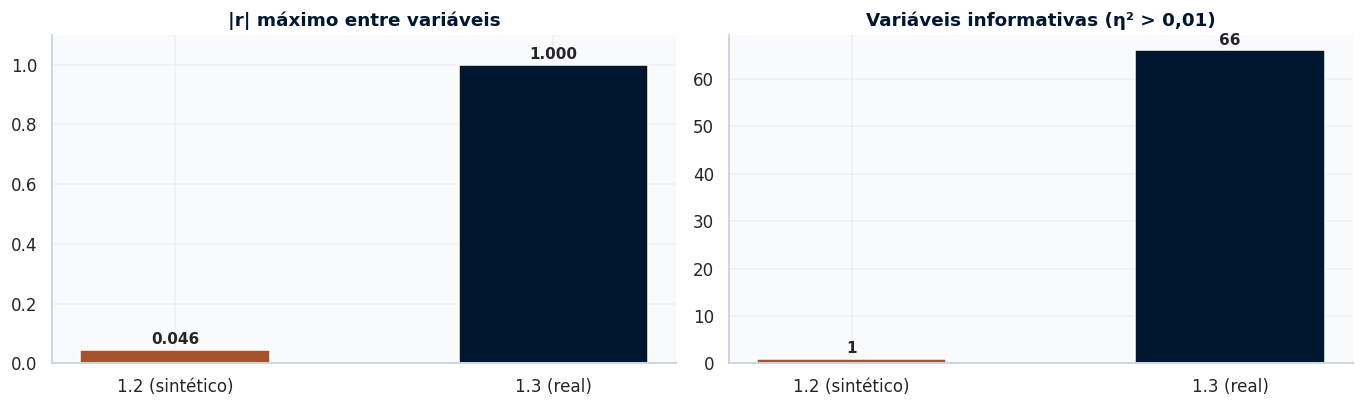

In [24]:
# @title ▶️ 12.2 Quadro comparativo
fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))

ax[0].bar(["1.2 (sintético)", "1.3 (real)"],
          [R["1.2"]["corr_max_entre_features"], 1.0],
          color=[nu.PALETA["rust"], nu.PALETA["navy"]], width=.5)
ax[0].set_title("|r| máximo entre variáveis"); ax[0].set_ylim(0, 1.1)
for i, v in enumerate([R["1.2"]["corr_max_entre_features"], 1.0]):
    ax[0].text(i, v + .02, f"{v:.3f}", ha="center", fontweight="bold")

ax[1].bar(["1.2 (sintético)", "1.3 (real)"],
          [R["1.2"]["features_informativas"], R["1.3"]["features_informativas"]],
          color=[nu.PALETA["rust"], nu.PALETA["navy"]], width=.5)
ax[1].set_title("Variáveis informativas (η² > 0,01)")
for i, v in enumerate([R["1.2"]["features_informativas"], R["1.3"]["features_informativas"]]):
    ax[1].text(i, v + 1.2, str(v), ha="center", fontweight="bold")

plt.tight_layout(); plt.show()

> ✅ **Leitura principal**
>
> Grandezas físicas relacionadas apresentam correlação. Na Entrega
> 1.3, `idle.*` e `*_iat.*` alcançam |r| próximo de 1,000 porque medem o mesmo fenômeno.
> Na Entrega 1.2, o máximo entre todos os pares é 0,046.

**Ausência de correlação onde o domínio a exige é a assinatura mais robusta de dado
fabricado** — mais robusta que a uniformidade, que pode ocorrer legitimamente.

### 12.3 Modos de falha consolidados

> 🎯 **Pergunta:** Reunir os seis modos de falha demonstrados nas três entregas.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Composição a partir dos JSONs. Cada linha registra a evidência numérica e o efeito sobre a conclusão.

</details>

In [25]:
# @title ▶️ 12.3 Modos de falha consolidados
tese = pd.DataFrame([
    {"entrega": "1.1", "modo de falha": "convenção silenciosa",
     "evidência": f"outliers da setosa: {R['1.1']['outliers_setosa_tipo7']} (tipo 7) "
                  f"contra {R['1.1']['outliers_setosa_tipo1']} (tipo 1)",
     "efeito": "critério de exclusão muda sem aviso"},
    {"entrega": "1.1", "modo de falha": "imputação anterior à análise",
     "evidência": f"dispersão de age contrai {R['1.1']['reducao_dispersao_por_imputacao_pct']}% "
                  f"({R['1.1']['age_ausentes_pct']}% imputado)",
     "efeito": "associação com o desfecho é atenuada"},
    {"entrega": "1.1", "modo de falha": "agregação sobre grupos heterogêneos",
     "evidência": f"r = {R['1.1']['simpson_agregado']:+} agregado contra "
                  f"{R['1.1']['simpson_por_especie']} por espécie",
     "efeito": "sinal da relação se inverte"},
    {"entrega": "1.1", "modo de falha": "remoção acrítica de duplicatas",
     "evidência": f"{R['1.1']['duplicatas_linha_inteira']} duplicatas legítimas, "
                  f"concentradas na 3ª classe",
     "efeito": "drop_duplicates eliminaria entidades distintas"},
    {"entrega": "1.2", "modo de falha": "proveniência não verificada",
     "evidência": f"{R['1.2']['features_informativas']} variável informativa; "
                  f"|r| máx {R['1.2']['corr_max_entre_features']}",
     "efeito": "análise exploratória produz ruído apresentado como achado"},
    {"entrega": "1.3", "modo de falha": "acurácia global sob desbalanceamento",
     "evidência": f"{R['1.3']['desbalanceamento']}:1; regra constante acerta "
                  f"{R['1.3']['acuracia_trivial_pct']}%",
     "efeito": "modelo sem capacidade preditiva parece adequado"},
    {"entrega": "1.3", "modo de falha": "assinatura tomada por aprendizado",
     "evidência": f"{R['1.3']['assinatura_definicional']['feature']} → "
                  f"{R['1.3']['assinatura_definicional']['classe']} "
                  f"(η² = {R['1.3']['assinatura_definicional']['eta2']})",
     "efeito": "modelo redescobre a definição do ataque"},
]).set_index("entrega")
pd.set_option("display.max_colwidth", 100)
tese

,modo de falha,evidência,efeito
entrega,,,
1.1,convenção silenciosa,outliers da setosa: 4 (tipo 7) contra 1 (tipo 1),critério de exclusão muda sem aviso
1.1,imputação anterior à análise,dispersão de age contrai 10.49% (19.87% imputado),associação com o desfecho é atenuada
1.1,agregação sobre grupos heterogêneos,"r = -0.1176 agregado contra [0.7425, 0.5259, 0.4572] por espécie",sinal da relação se inverte
1.1,remoção acrítica de duplicatas,"107 duplicatas legítimas, concentradas na 3ª classe",drop_duplicates eliminaria entidades distintas
1.2,proveniência não verificada,1 variável informativa; |r| máx 0.0461,análise exploratória produz ruído apresentado como achado
1.3,acurácia global sob desbalanceamento,3380.7:1; regra constante acerta 76.89%,modelo sem capacidade preditiva parece adequado
1.3,assinatura tomada por aprendizado,fwd_URG_flag_count → NMAP_XMAS_TREE_SCAN (η² = 0.998),modelo redescobre a definição do ataque


> ✅ **Leitura principal**
>
> Sete modos de falha, nenhum dos quais produz erro de execução,
> aviso ou valor visivelmente anômalo. Todos alteram a conclusão.

Esta é a tese da Entrega 1: **convenções e proveniência determinam conclusões tanto
quanto os dados.**

---

## 🚀 13. Conclusões e recomendações

### 13.1 Resposta à questão de pesquisa

**Os dispositivos IoT em operação normal possuem assinatura comportamental própria.**

**37 das 80** variáveis avaliadas separam `Thing_Speak`, `MQTT_Publish` e `Wipro_bulb`
entre si, com predominância das variáveis temporais (`idle.*`, `*_iat.*`). O
perfilamento de linha de base por dispositivo é viável neste conjunto.

A assinatura reside no **comportamento temporal**, não no conteúdo do pacote — o que
implica que conteúdo cifrado não impede o perfilamento.

### 13.2 Estabilidade da linha de base

| Dispositivo | QCD | Zeros em `idle.min` | Regularidade |
|---|---|---|---|
| `MQTT_Publish` | 0,347 | 5,0% | alta |
| `Thing_Speak` | 0,934 | 98,9% | baixa |
| `Wipro_bulb` | 0,998 | 68,4% | muito baixa |

A regularidade **não é uniforme entre dispositivos**, e isso determina a viabilidade de
detecção por desvio em cada um.

### 13.3 Achados metodológicos

| # | Achado | Quantificação |
|---|---|---|
| 1 | Desbalanceamento extremo | 3.381 : 1 · acurácia trivial 76,89% · duas classes com menos de 40 registros |
| 2 | Assinatura distinta de anomalia | `fwd_URG_flag_count` resolve o Xmas scan por definição (η² = 0,998) |
| 3 | Colinearidade estrutural | 52 pares com \|r\| > 0,95, alguns próximos de 1,000 |

### 13.4 Recomendações operacionais

1. **Calibrar o limiar de anomalia por dispositivo**, a partir do QCD observado de cada
   um. Limiar único para a rede é inadequado quando a regularidade varia de 0,35 a 1,00.
2. **Separar assinatura de anomalia na arquitetura do detector**: regra determinística
   para o que é definicional, modelo comportamental para o restante.
3. **Reduzir dimensionalidade antes de modelar.** Os 52 pares redundantes inflam a
   importância aparente das famílias duplicadas.
4. **Não reportar acurácia global** sem comparação explícita com $p_{\max} = 76{,}89\%$.

### 13.5 Conclusão da Entrega 1

As três entregas compõem um argumento único:

- **1.1** — a *convenção* de cálculo altera o resultado (quatro outliers ou um).
- **1.2** — a *proveniência* do dado determina se há resultado (uma variável informativa
  entre dezenove).
- **1.3** — o *enquadramento* da questão determina se o resultado significa algo (76,89%
  de acurácia sem capacidade preditiva).

Nenhuma das três falhas produz erro. Todas alteram a conclusão.

### 13.6 Continuidade

1. Redução de dimensionalidade por análise de componentes principais ou seleção por
   informação mútua.
2. Detector de anomalia não supervisionado por dispositivo, a partir da linha de base da
   Seção 8.
3. Validação em captura de rede operacional, não de bancada.

---

## 💾 Apêndice A — Registro de decisões

Decisões metodológicas tomadas nesta entrega, com a alternativa descartada e a
justificativa. Serve para que a revisão questione a escolha, não a omissão.

| Decisão | Alternativa descartada | Justificativa |
|---|---|---|
| Perfilamento de linha de base em vez de classificação supervisionada | classificador multiclasse com métricas por classe | desbalanceamento de 3.381:1 e duas classes com menos de 40 registros tornam as métricas das classes raras ruído amostral |
| Não aplicar balanceamento de classes | SMOTE ou subamostragem | reamostrar antes da análise exploratória descreveria a amostra sintética, não a rede; balanceamento pertence ao fold de treino |
| Não buscar repetição semântica por igualdade exata | `drop_duplicates()` como suficiente | com 85 colunas contínuas de resolução microssegundo, fluxos equivalentes divergem numericamente; a verificação exata retorna zero e não é conclusiva sobre repetição |
| QCD em vez de IQR/mediana | razão IQR/mediana | indefinida sob inflação de zeros — a primeira versão produziu `inf` em dois dos três dispositivos; registrado em vez de suprimido |
| `flow_duration` em vez de `idle.min` na Seção 8.3 | manter `idle.min` | 98,9% de zeros no Thing_Speak inviabiliza métrica baseada em quartis; a inflação passou a ser reportada como dimensão própria |
| `fill_value=0` na contagem e não na mediana (9.1) | aplicar a ambas | zero fluxos é informação; mediana zero em célula vazia seria valor fabricado |
| Escala symlog nos gráficos de duração | escala linear | as distribuições cobrem várias ordens de grandeza; em linear a separação é invisível |
| Sem cruzamento entre os três conjuntos | junção por chave comum | não há chave, entidade nem unidade de observação compartilhada; a comparação possível é metodológica |


---

## 🧰 Apêndice B — Referência rápida

**Desbalanceamento**

```python
vc = df[alvo].value_counts()
razao = vc.max() / vc.min()
p_max = vc.max() / len(df)              # acurácia do classificador constante
(vc / len(df)).cumsum()                 # Pareto acumulado
```

**Separação e vazamento**

```python
nu._eta2(df, 'variavel', 'alvo')        # SQ_entre / SQ_total
nu.suspeitos_de_vazamento(df, 'alvo')
# η² > 0,95 exige investigação: aprendizado ou definição?
```

**Colinearidade**

```python
num_var = [c for c in num if df[c].nunique() > 1]   # exclui constantes
cc = df[num_var].corr().abs()
pares = [(a, b) for i, a in enumerate(cc.columns)
         for b in cc.columns[i+1:] if cc.loc[a, b] > .95]
```

**Linha de base por dispositivo**

```python
est = sub.groupby('disp', observed=True)['flow_duration'].agg(
    q1=lambda s: s.quantile(.25), q3=lambda s: s.quantile(.75))
est['QCD'] = (est.q3 - est.q1) / (est.q3 + est.q1)   # robusto a mediana zero
sub.groupby('disp')['idle.min'].apply(lambda s: (s == 0).mean())
```

**Cruzamentos**

```python
df.pivot_table(values=, index=, columns=, aggfunc='count', fill_value=0)
df.pivot_table(values=, index=, columns=, aggfunc='median')   # sem fill_value
pd.crosstab(a, b, normalize='columns')
df.groupby(k, observed=True)['c'].describe()
```